# Lab Experiment: Comparison of Logistic Regression and KNN Classifiers

Aim: To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 2. Load the dataset

The dataset file wdbc.data has no header row. Column names are added based on the wdbc.names file.

In [2]:
features = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness',
            'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

columns = ['id', 'diagnosis'] + [f'{stat}_{f}' for stat in ['mean', 'se', 'worst'] for f in features]

df = pd.read_csv('data/wdbc.data', header=None, names=columns)
df.head()

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.shape

(569, 32)

Dataset has 569 rows and 32 columns (id, diagnosis and 30 numeric features).

## 3. Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   mean_radius              569 non-null    float64
 3   mean_texture             569 non-null    float64
 4   mean_perimeter           569 non-null    float64
 5   mean_area                569 non-null    float64
 6   mean_smoothness          569 non-null    float64
 7   mean_compactness         569 non-null    float64
 8   mean_concavity           569 non-null    float64
 9   mean_concave_points      569 non-null    float64
 10  mean_symmetry            569 non-null    float64
 11  mean_fractal_dimension   569 non-null    float64
 12  se_radius                569 non-null    float64
 13  se_texture               569 non-null    float64
 14  se_perimeter             569 non-null

In [5]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

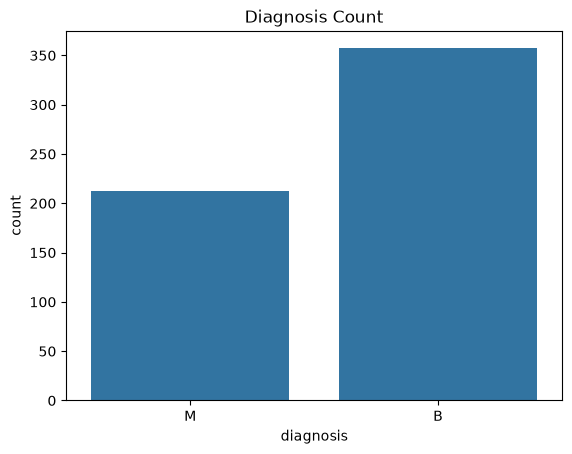

In [6]:
sns.countplot(x='diagnosis', data=df)
plt.title('Diagnosis Count')
plt.show()

Out of 569 patients, 357 are benign (B) and 212 are malignant (M). The classes are not equal but not too imbalanced either.

In [7]:
df.describe()

,id,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


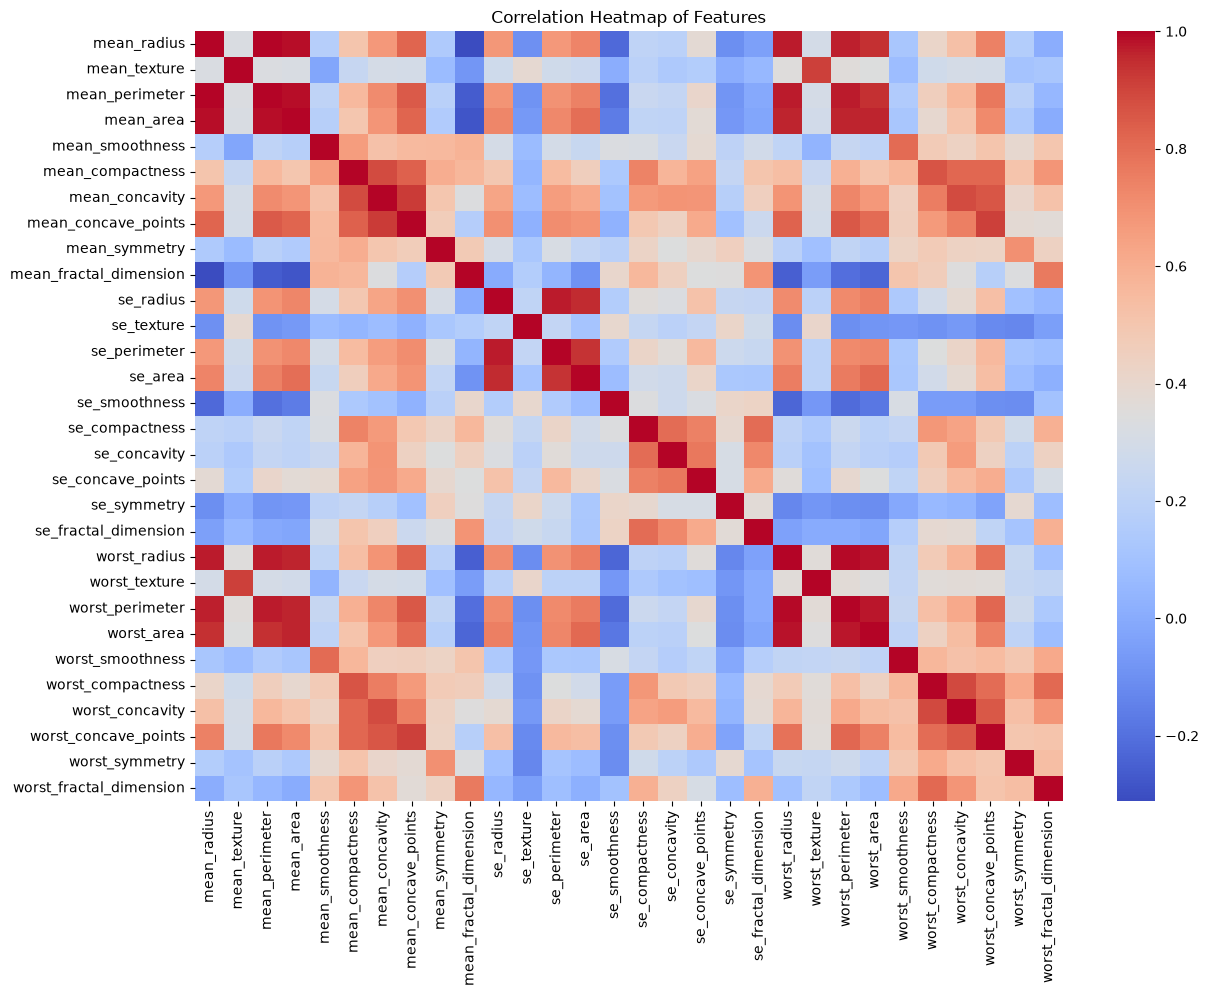

In [8]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(['id', 'diagnosis'], axis=1).corr(), cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

Many of the mean, se and worst versions of the same feature are highly correlated with each other, like radius, perimeter and area. This is expected since they are derived from the same cell shape.

## 4. Check missing values

In [9]:
df.isnull().sum().sum()

np.int64(0)

There are no missing values in the dataset, so no imputation is needed.

## 5. Data preprocessing

In [10]:
df = df.drop('id', axis=1)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

id column is dropped since it has no predictive value. diagnosis is encoded as 1 for malignant and 0 for benign.

In [11]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

## 6. Train test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((455, 30), (114, 30))

Data is split into 80% training and 20% testing. stratify=y keeps the same ratio of benign to malignant in both sets.

## 7. Feature scaling

KNN uses distance between points so features need to be on the same scale. Scaling is applied for both models to keep comparison fair.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Train Logistic Regression classifier

In [14]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

## 9. Train KNN classifier

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

## 10. Evaluation

In [16]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

lr_metrics = get_metrics(y_test, y_pred_lr)
knn_metrics = get_metrics(y_test, y_pred_knn)

lr_metrics

{'Accuracy': 0.9649122807017544,
 'Precision': 0.975,
 'Recall': 0.9285714285714286,
 'F1 Score': 0.9512195121951219}

In [17]:
knn_metrics

{'Accuracy': 0.956140350877193,
 'Precision': 0.9743589743589743,
 'Recall': 0.9047619047619048,
 'F1 Score': 0.9382716049382716}

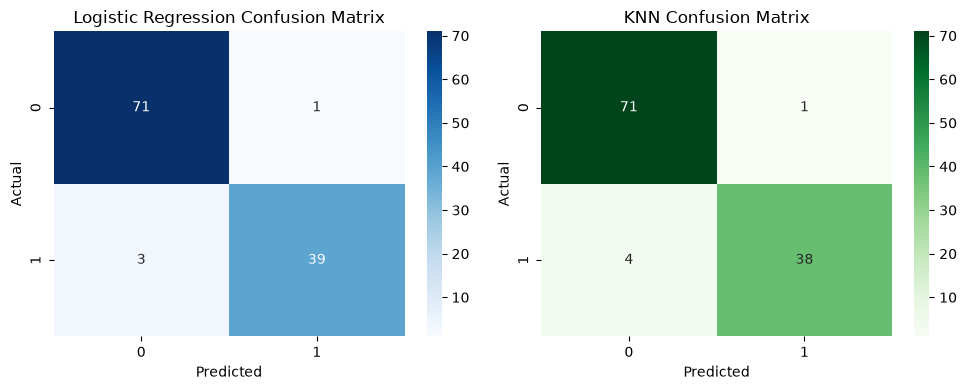

In [18]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('KNN Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Logistic Regression made 4 wrong predictions out of 114 test samples (1 false positive, 3 false negatives). KNN made 5 wrong predictions (1 false positive, 4 false negatives). Both models are confusing malignant cases as benign more than the other way around.

## 11. Comparison table

In [19]:
comparison = pd.DataFrame([lr_metrics, knn_metrics], index=['Logistic Regression', 'KNN'])
comparison

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.964912,0.975000,0.928571,0.951220
KNN,0.956140,0.974359,0.904762,0.938272


## 12. Interpretation

Logistic Regression got 96.5% accuracy and KNN got 95.6% accuracy on the test set. Logistic Regression is also slightly better in recall (0.93 vs 0.90) and F1 score (0.95 vs 0.94), while precision is almost the same for both (about 0.97).

Recall matters a lot in this problem because missing a malignant case (false negative) is more dangerous than a false alarm. Logistic Regression had 3 false negatives compared to 4 for KNN, so it is doing slightly better on this front too.

Overall Logistic Regression performs a bit better than KNN on this dataset across all four metrics. This makes sense because the classes are described in the dataset documentation as linearly separable, which favors a linear model like Logistic Regression.